## Data Understanding & Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rides_df = pd.read_csv("smartride_rides.csv")
drivers_df = pd.read_json("smartride_drivers.json")

In [3]:
rides_df.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad


In [4]:
drivers_df.head()

,driver_id,experience,rating
0,1,14,3.98
1,2,14,2.77
2,3,8,4.95
3,4,8,2.61
4,5,13,2.66


In [5]:
rides_df.shape

(5000, 6)

In [6]:
drivers_df.shape

(200, 3)

In [7]:
rides_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ride_id          5000 non-null   int64  
 1   distance_km      4754 non-null   float64
 2   fare_amount      4523 non-null   float64
 3   pickup_datetime  5000 non-null   object 
 4   traffic_level    4737 non-null   object 
 5   city             5000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB


In [8]:
drivers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   driver_id   200 non-null    int64  
 1   experience  200 non-null    int64  
 2   rating      200 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 4.8 KB


In [9]:
rides_df.describe()

,ride_id,distance_km,fare_amount
count,5000.000000,4754.000000,4523.000000
mean,2500.500000,15.396346,281.926741
std,1443.520003,8.378683,481.496319
min,1.000000,1.010000,8.780000
25%,1250.750000,8.152500,109.435000
50%,2500.500000,15.420000,206.070000
75%,3750.250000,22.407500,317.225000
max,5000.000000,30.000000,4939.830000


In [10]:
rides_df.dtypes

,0
ride_id,int64
distance_km,float64
fare_amount,float64
pickup_datetime,object
traffic_level,object
city,object


In [11]:
rides_df['traffic_level'].value_counts()

,count
traffic_level,
Low,1614
Medium,1565
High,1558


In [12]:
rides_df['city'].value_counts()

,count
city,
Mumbai,1034
Delhi,1000
Surat,995
Bangalore,988
Ahmedabad,983


## Data Cleaning

In [13]:
rides_df.isnull().sum()

,0
ride_id,0
distance_km,246
fare_amount,477
pickup_datetime,0
traffic_level,263
city,0


In [14]:
rides_df[['distance_km', 'fare_amount', 'traffic_level']].isnull().sum()

,0
distance_km,246
fare_amount,477
traffic_level,263


<Axes: xlabel='distance_km'>

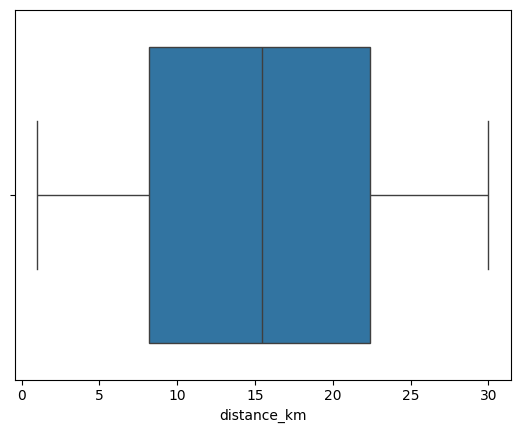

In [15]:
sns.boxplot(data=rides_df, x='distance_km')

<Axes: xlabel='fare_amount'>

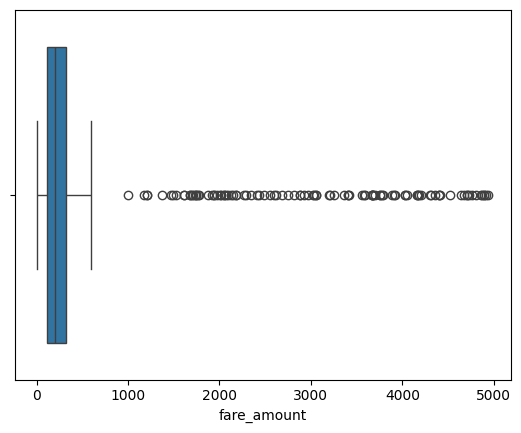

In [16]:
sns.boxplot(data=rides_df, x='fare_amount')

In [17]:
rides_df['fare_amount__'] = rides_df['fare_amount'].fillna(rides_df['fare_amount'].median())
rides_df['distance_km__'] = rides_df['distance_km'].fillna(rides_df['distance_km'].mean())
rides_df['traffic_level__'] = rides_df['traffic_level'].fillna(rides_df['traffic_level'].mode()[0])

In [18]:
rides_df[['fare_amount__', 'distance_km__', 'traffic_level__']].isnull().sum()

,0
fare_amount__,0
distance_km__,0
traffic_level__,0


In [19]:
rides_df.pickup_datetime = pd.to_datetime(rides_df.pickup_datetime)

In [20]:
rides_df.dtypes

,0
ride_id,int64
distance_km,float64
fare_amount,float64
pickup_datetime,datetime64[ns]
traffic_level,object
city,object
fare_amount__,float64
distance_km__,float64
traffic_level__,object


In [21]:
rides_df.duplicated().sum()

np.int64(0)

In [22]:
ndf = rides_df.drop_duplicates()

## Exploratory Data Analysis (EDA)

<Axes: xlabel='traffic_level', ylabel='count'>

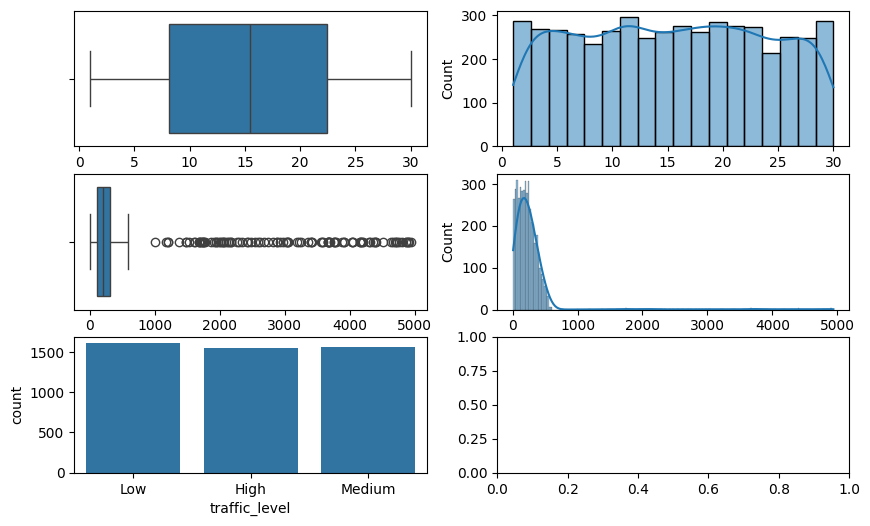

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(10, 6))

sns.boxplot(data=rides_df, x='distance_km', ax=axes[0, 0])
sns.histplot(data=rides_df, x='distance_km', kde=True, ax=axes[0, 1])

sns.boxplot(data=rides_df, x='fare_amount', ax=axes[1, 0])
sns.histplot(data=rides_df, x='fare_amount', kde=True, ax=axes[1, 1])

sns.countplot(data=rides_df, x='traffic_level', ax=axes[2, 0])

<Axes: xlabel='traffic_level', ylabel='fare_amount'>

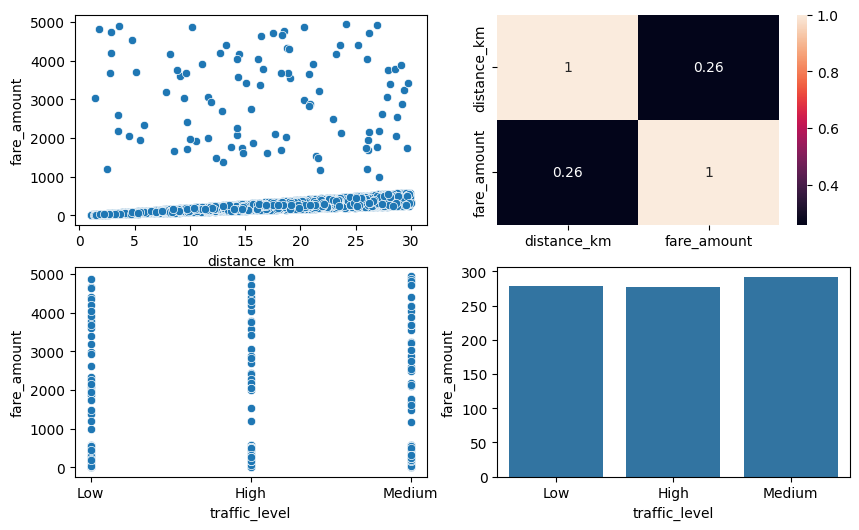

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

corr_mat = rides_df[['distance_km', 'fare_amount']].corr()

sns.scatterplot(data=rides_df, x='distance_km', y='fare_amount', ax=axes[0, 0])
sns.heatmap(corr_mat, ax=axes[0, 1], annot=True)

sns.scatterplot(data=rides_df, x='traffic_level', y='fare_amount', ax=axes[1, 0])
sns.barplot(data=rides_df, x='traffic_level', y='fare_amount', errorbar=None, ax=axes[1, 1])


<Axes: >

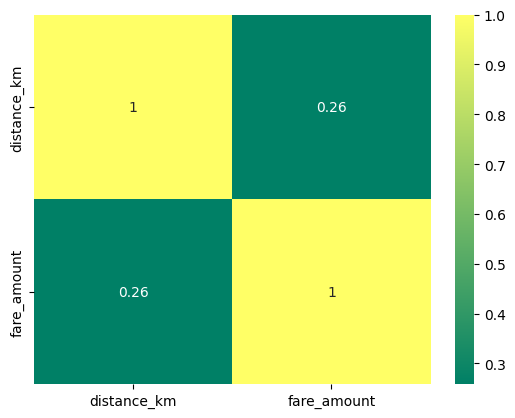

In [25]:
full_corr_mat = rides_df[['distance_km', 'fare_amount']].corr()

sns.heatmap(full_corr_mat, annot=True, cmap='summer')

<Axes: xlabel='distance_km__', ylabel='fare_amount__'>

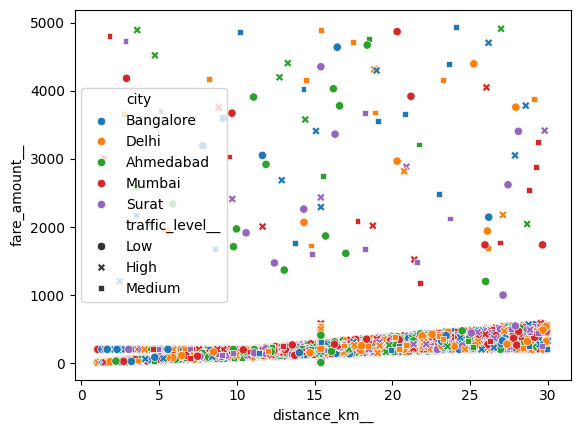

In [26]:
sns.scatterplot(data=rides_df, x='distance_km__', y='fare_amount__', hue='city', style='traffic_level__')

<Axes: xlabel='city', ylabel='fare_amount__'>

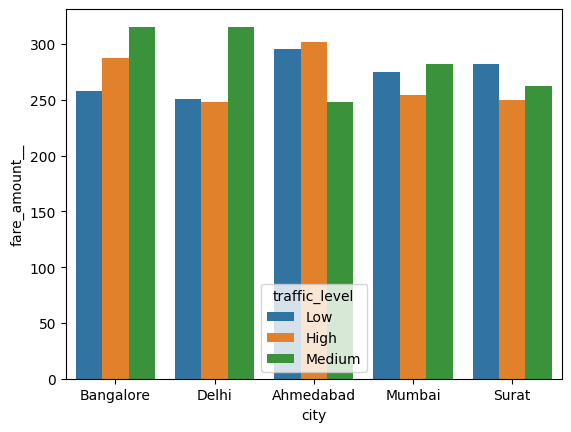

In [27]:
sns.barplot(data=rides_df, x='city', y='fare_amount__', hue='traffic_level', errorbar=None)

## Missing Value Treatment

In [39]:
from sklearn.impute import SimpleImputer

ss = SimpleImputer(strategy='most_frequent')
arr = ss.fit_transform(rides_df[['traffic_level']])

rides_df['traffic_level_mf'] = pd.DataFrame(arr, columns=['traffic_level_mf'])

rides_df['traffic_level_mf'].isnull().sum()

np.int64(0)

In [38]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=10)
arr = knn.fit_transform(rides_df[['distance_km']])

rides_df['distance_km_knn'] = pd.DataFrame(arr, columns=['distance_km_knn'])

rides_df['distance_km_knn'].isnull().sum()

np.int64(0)

In [40]:
knn1 = KNNImputer(n_neighbors=10)
arr1 = knn1.fit_transform(rides_df[['fare_amount']])

rides_df['fare_amount_knn'] = pd.DataFrame(arr1, columns=['fare_amount_knn'])

rides_df['fare_amount_knn'].isnull().sum()

np.int64(0)

## Outlier Detection & Handling

<Axes: xlabel='fare_amount'>

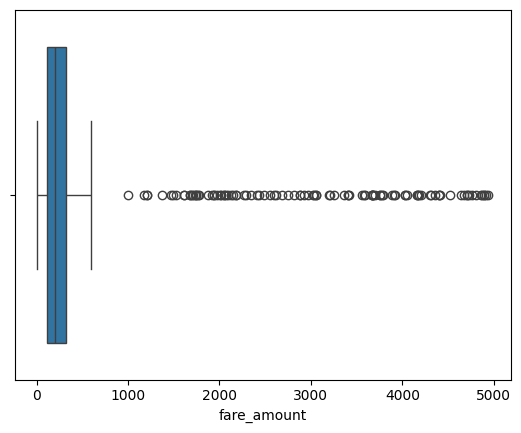

In [42]:
sns.boxplot(data=rides_df, x='fare_amount')

In [44]:
q1 = rides_df['fare_amount'].quantile(0.25)
q3 = rides_df['fare_amount'].quantile(0.75)

iqr = q3 - q1

lower_fence = q1 - 1.5*iqr
upper_fence = q3 + 1.5*iqr

outlier_mask = (rides_df['fare_amount'] < lower_fence) | (rides_df['fare_amount'] > upper_fence)
outliers = rides_df[outlier_mask]
outliers


,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,fare_amount__,distance_km__,traffic_level__,traffic_level_mf,distance_km_knn,fare_amount_knn
221,222,9.13,3595.03,2026-02-08 20:46:54,Low,Bangalore,3595.03,9.130000,Low,Low,9.130000,3595.03
235,236,12.88,2687.96,2026-03-30 19:46:54,High,Bangalore,2687.96,12.880000,High,High,12.880000,2687.96
298,299,NaN,2435.55,2026-02-08 13:46:54,High,Surat,2435.55,15.396346,High,High,15.396346,2435.55
330,331,13.04,1369.38,2026-03-31 05:46:54,Low,Ahmedabad,1369.38,13.040000,Low,Low,13.040000,1369.38
448,449,26.93,1774.09,2026-03-18 06:46:54,Medium,Mumbai,1774.09,26.930000,Medium,Medium,26.930000,1774.09
...,...,...,...,...,...,...,...,...,...,...,...,...
4818,4819,18.98,4298.84,2026-03-27 08:46:54,High,Bangalore,4298.84,18.980000,High,High,18.980000,4298.84
4877,4878,29.10,3884.49,2026-03-31 07:46:54,Medium,Delhi,3884.49,29.100000,Medium,Medium,29.100000,3884.49
4896,4897,17.49,4710.57,2026-02-24 16:46:54,Medium,Delhi,4710.57,17.490000,Medium,Medium,17.490000,4710.57
4908,4909,16.31,3363.86,2026-02-25 23:46:54,NaN,Surat,3363.86,16.310000,Low,Low,16.310000,3363.86


In [45]:
final_rides_df = rides_df[~outlier_mask]

final_rides_df

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,fare_amount__,distance_km__,traffic_level__,traffic_level_mf,distance_km_knn,fare_amount_knn
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,135.18,11.930000,Low,Low,11.930000,135.18
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,180.06,11.050000,High,High,11.050000,180.06
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,19.51,1.480000,Low,Low,1.480000,19.51
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,147.11,14.810000,High,High,14.810000,147.11
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,436.55,22.650000,High,High,22.650000,436.55
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,33.03,2.220000,Low,Low,2.220000,33.03
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,230.77,28.370000,Medium,Medium,28.370000,230.77
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,252.67,12.970000,Medium,Medium,12.970000,252.67
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,197.99,10.410000,Low,Low,10.410000,197.99


In [47]:
print(f"Before: {rides_df.shape[0]} Records")
print(f"After: {final_rides_df.shape[0]} Records")

print(f"Total Outliers removed: {rides_df.shape[0] - final_rides_df.shape[0]}")


Before: 5000 Records
After: 4895 Records
Total Outliers removed: 105


## Feature Engineering

In [50]:
final_rides_df['month'] = final_rides_df['pickup_datetime'].dt.month
final_rides_df['day'] = final_rides_df['pickup_datetime'].dt.day
final_rides_df['hour'] = final_rides_df['pickup_datetime'].dt.hour

final_rides_df.head()

/tmp/ipykernel_1459/260182656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rides_df['month'] = final_rides_df['pickup_datetime'].dt.month
/tmp/ipykernel_1459/260182656.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rides_df['day'] = final_rides_df['pickup_datetime'].dt.day
/tmp/ipykernel_1459/260182656.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,fare_amount__,distance_km__,traffic_level__,traffic_level_mf,distance_km_knn,fare_amount_knn,month,day,hour
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,135.18,11.93,Low,Low,11.93,135.18,2,5,19
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,180.06,11.05,High,High,11.05,180.06,2,27,6
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,19.51,1.48,Low,Low,1.48,19.51,2,17,7
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,147.11,14.81,High,High,14.81,147.11,3,19,10
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,436.55,22.65,High,High,22.65,436.55,3,1,1


In [55]:
op = final_rides_df['hour'].value_counts(ascending=False)

peak_hours = op.index[:5]

peak_hours

Index([22, 20, 6, 19, 16], dtype='int32', name='hour')

In [56]:
def identify_peak_hour(hr):
  if hr in peak_hours:
    return 1
  else:
    return 0

final_rides_df['is_peak_hr'] = final_rides_df['hour'].apply(identify_peak_hour)

/tmp/ipykernel_1459/4101914199.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rides_df['is_peak_hr'] = final_rides_df['hour'].apply(identify_peak_hour)


In [57]:
final_rides_df.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,fare_amount__,distance_km__,traffic_level__,traffic_level_mf,distance_km_knn,fare_amount_knn,month,day,hour,is_peak_hr
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,135.18,11.93,Low,Low,11.93,135.18,2,5,19,1
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,180.06,11.05,High,High,11.05,180.06,2,27,6,1
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,19.51,1.48,Low,Low,1.48,19.51,2,17,7,0
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,147.11,14.81,High,High,14.81,147.11,3,19,10,0
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,436.55,22.65,High,High,22.65,436.55,3,1,1,0


In [58]:
final_rides_df['distance_km'].describe()

,distance_km
count,4653.000000
mean,15.363318
std,8.381580
min,1.010000
25%,8.080000
50%,15.370000
75%,22.380000
max,30.000000


In [59]:
def categorize_distance(dist):
  if dist >=1 and dist <=10:
    return 0      # "Short"
  elif dist >=11 and dist <=20:
    return 1      # "Medium"
  else:
    return 2      # "Long"

final_rides_df['dist_cat'] = final_rides_df['distance_km'].apply(categorize_distance)

final_rides_df.head()

/tmp/ipykernel_1459/1056529747.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rides_df['dist_cat'] = final_rides_df['distance_km'].apply(categorize_distance)


,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,fare_amount__,distance_km__,traffic_level__,traffic_level_mf,distance_km_knn,fare_amount_knn,month,day,hour,is_peak_hr,dist_cat
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,135.18,11.93,Low,Low,11.93,135.18,2,5,19,1,1
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,180.06,11.05,High,High,11.05,180.06,2,27,6,1,1
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,19.51,1.48,Low,Low,1.48,19.51,2,17,7,0,0
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,147.11,14.81,High,High,14.81,147.11,3,19,10,0,1
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,436.55,22.65,High,High,22.65,436.55,3,1,1,0,2


## Handling Mixed Variables

In [60]:
final_rides_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4895 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ride_id           4895 non-null   int64         
 1   distance_km       4653 non-null   float64       
 2   fare_amount       4418 non-null   float64       
 3   pickup_datetime   4895 non-null   datetime64[ns]
 4   traffic_level     4638 non-null   object        
 5   city              4895 non-null   object        
 6   fare_amount__     4895 non-null   float64       
 7   distance_km__     4895 non-null   float64       
 8   traffic_level__   4895 non-null   object        
 9   traffic_level_mf  4895 non-null   object        
 10  distance_km_knn   4895 non-null   float64       
 11  fare_amount_knn   4895 non-null   float64       
 12  month             4895 non-null   int32         
 13  day               4895 non-null   int32         
 14  hour              4895 non-nu

No any feature contains mixed or combined values. So no need to handle it.

In [63]:
final_rides_df = final_rides_df.drop(columns=['traffic_level', 'traffic_level__', 'distance_km', 'distance_km__', 'fare_amount', 'fare_amount__'])

In [64]:
final_rides_df.head()

,ride_id,pickup_datetime,city,traffic_level_mf,distance_km_knn,fare_amount_knn,month,day,hour,is_peak_hr,dist_cat
0,1,2026-02-05 19:46:54,Bangalore,Low,11.93,135.18,2,5,19,1,1
1,2,2026-02-27 06:46:54,Delhi,High,11.05,180.06,2,27,6,1,1
2,3,2026-02-17 07:46:54,Bangalore,Low,1.48,19.51,2,17,7,0,0
3,4,2026-03-19 10:46:54,Bangalore,High,14.81,147.11,3,19,10,0,1
4,5,2026-03-01 01:46:54,Ahmedabad,High,22.65,436.55,3,1,1,0,2


## Encoding Categorical Data

In [68]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

le = LabelEncoder()
oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])

final_rides_df['city'] = le.fit_transform(final_rides_df[['city']])
final_rides_df['traffic_level'] = oe.fit_transform(final_rides_df[['traffic_level_mf']])

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [69]:
final_rides_df.head()

,ride_id,pickup_datetime,city,traffic_level_mf,distance_km_knn,fare_amount_knn,month,day,hour,is_peak_hr,dist_cat,traffic_level
0,1,2026-02-05 19:46:54,1,Low,11.93,135.18,2,5,19,1,1,0.0
1,2,2026-02-27 06:46:54,2,High,11.05,180.06,2,27,6,1,1,2.0
2,3,2026-02-17 07:46:54,1,Low,1.48,19.51,2,17,7,0,0,0.0
3,4,2026-03-19 10:46:54,1,High,14.81,147.11,3,19,10,0,1,2.0
4,5,2026-03-01 01:46:54,0,High,22.65,436.55,3,1,1,0,2,2.0


In [71]:
final_rides_df = final_rides_df.drop(columns=['traffic_level_mf'])

final_rides_df.head()

,ride_id,pickup_datetime,city,distance_km_knn,fare_amount_knn,month,day,hour,is_peak_hr,dist_cat,traffic_level
0,1,2026-02-05 19:46:54,1,11.93,135.18,2,5,19,1,1,0.0
1,2,2026-02-27 06:46:54,2,11.05,180.06,2,27,6,1,1,2.0
2,3,2026-02-17 07:46:54,1,1.48,19.51,2,17,7,0,0,0.0
3,4,2026-03-19 10:46:54,1,14.81,147.11,3,19,10,0,1,2.0
4,5,2026-03-01 01:46:54,0,22.65,436.55,3,1,1,0,2,2.0


In [73]:
final_rides_df.dtypes

,0
ride_id,int64
pickup_datetime,datetime64[ns]
city,int64
distance_km_knn,float64
fare_amount_knn,float64
month,int32
day,int32
hour,int32
is_peak_hr,int64
dist_cat,int64


## Numerical Feature Transformation

In [77]:
from sklearn.preprocessing import KBinsDiscretizer

q_binning = KBinsDiscretizer(strategy='quantile', n_bins=3, encode='ordinal')

arr = q_binning.fit_transform(final_rides_df[['distance_km_knn']])

final_rides_df['distance_km_bins'] = pd.DataFrame(arr, columns=['distance_km_bins'])

final_rides_df = final_rides_df.drop(columns=['distance_km_knn'])

final_rides_df.head()

,ride_id,pickup_datetime,city,fare_amount_knn,month,day,hour,is_peak_hr,dist_cat,traffic_level,distance_km_bins
0,1,2026-02-05 19:46:54,1,135.18,2,5,19,1,1,0.0,1.0
1,2,2026-02-27 06:46:54,2,180.06,2,27,6,1,1,2.0,0.0
2,3,2026-02-17 07:46:54,1,19.51,2,17,7,0,0,0.0,0.0
3,4,2026-03-19 10:46:54,1,147.11,3,19,10,0,1,2.0,1.0
4,5,2026-03-01 01:46:54,0,436.55,3,1,1,0,2,2.0,2.0


In [78]:
from sklearn.preprocessing import KBinsDiscretizer

km_binning = KBinsDiscretizer(strategy='kmeans', encode='ordinal')

arr1 = km_binning.fit_transform(final_rides_df[['fare_amount_knn']])

final_rides_df['fare_amount_bins'] = pd.DataFrame(arr1, columns=['fare_amount_bins'])

final_rides_df = final_rides_df.drop(columns=['fare_amount_knn'])

final_rides_df.head()

,ride_id,pickup_datetime,city,month,day,hour,is_peak_hr,dist_cat,traffic_level,distance_km_bins,fare_amount_bins
0,1,2026-02-05 19:46:54,1,2,5,19,1,1,0.0,1.0,1.0
1,2,2026-02-27 06:46:54,2,2,27,6,1,1,2.0,0.0,1.0
2,3,2026-02-17 07:46:54,1,2,17,7,0,0,0.0,0.0,0.0
3,4,2026-03-19 10:46:54,1,3,19,10,0,1,2.0,1.0,1.0
4,5,2026-03-01 01:46:54,0,3,1,1,0,2,2.0,2.0,4.0


## Feature Scaling

In [81]:
from sklearn.preprocessing import StandardScaler

ss_month = StandardScaler()
ss_day = StandardScaler()
ss_hour = StandardScaler()

final_rides_df['month'] = ss_month.fit_transform(final_rides_df[['month']])
final_rides_df['day'] = ss_day.fit_transform(final_rides_df[['day']])
final_rides_df['hour'] = ss_hour.fit_transform(final_rides_df[['hour']])


final_rides_df.head()


,ride_id,pickup_datetime,city,month,day,hour,is_peak_hr,dist_cat,traffic_level,distance_km_bins,fare_amount_bins
0,1,2026-02-05 19:46:54,1,-1.145605,-1.156358,1.048029,1,1,0.0,1.0,1.0
1,2,2026-02-27 06:46:54,2,-1.145605,1.399692,-0.832772,1,1,2.0,0.0,1.0
2,3,2026-02-17 07:46:54,1,-1.145605,0.237851,-0.688095,0,0,0.0,0.0,0.0
3,4,2026-03-19 10:46:54,1,0.419490,0.470219,-0.254064,0,1,2.0,1.0,1.0
4,5,2026-03-01 01:46:54,0,0.419490,-1.621095,-1.556157,0,2,2.0,2.0,4.0


## Feature Transformation

<Axes: xlabel='month', ylabel='Count'>

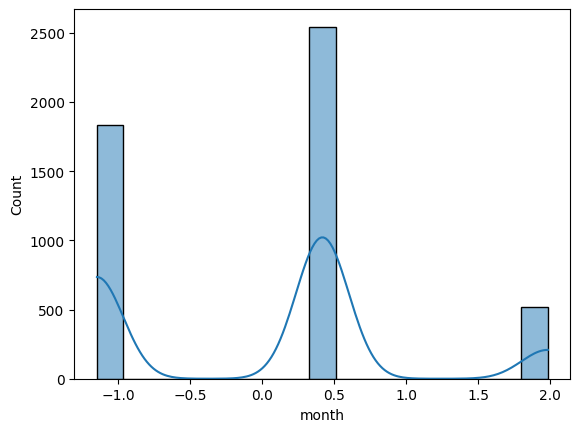

In [82]:
sns.histplot(data=final_rides_df, x='month', kde=True)

<Axes: xlabel='day', ylabel='Count'>

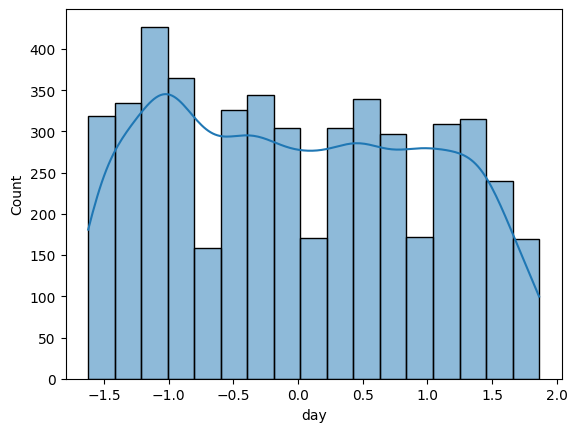

In [83]:
sns.histplot(data=final_rides_df, x='day', kde=True)

<Axes: xlabel='hour', ylabel='Count'>

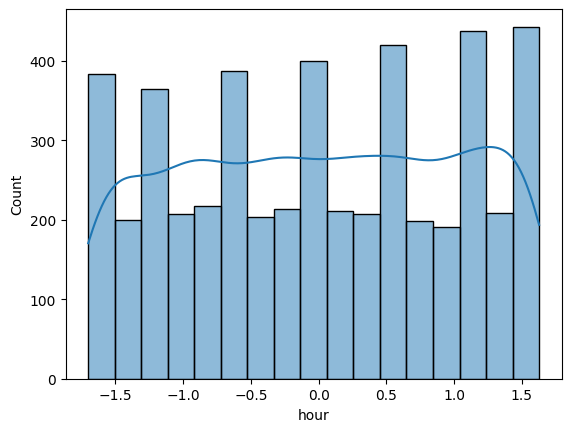

In [84]:
sns.histplot(data=final_rides_df, x='hour', kde=True)

In [87]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

final_rides_df[['month_transformed']] = pt.fit_transform(final_rides_df[['month']])

final_rides_df.head()

,ride_id,pickup_datetime,city,month,day,hour,is_peak_hr,dist_cat,traffic_level,distance_km_bins,fare_amount_bins,month_transformed
0,1,2026-02-05 19:46:54,1,-1.145605,-1.156358,1.048029,1,1,0.0,1.0,1.0,-1.174189
1,2,2026-02-27 06:46:54,2,-1.145605,1.399692,-0.832772,1,1,2.0,0.0,1.0,-1.174189
2,3,2026-02-17 07:46:54,1,-1.145605,0.237851,-0.688095,0,0,0.0,0.0,0.0,-1.174189
3,4,2026-03-19 10:46:54,1,0.419490,0.470219,-0.254064,0,1,2.0,1.0,1.0,0.462154
4,5,2026-03-01 01:46:54,0,0.419490,-1.621095,-1.556157,0,2,2.0,2.0,4.0,0.462154


In [88]:
pt1 = PowerTransformer(method='yeo-johnson')
pt2 = PowerTransformer(method='yeo-johnson')

final_rides_df[['day_transformed']] = pt1.fit_transform(final_rides_df[['day']])
final_rides_df[['hour_transformed']] = pt2.fit_transform(final_rides_df[['hour']])

final_rides_df.head()

,ride_id,pickup_datetime,city,month,day,hour,is_peak_hr,dist_cat,traffic_level,distance_km_bins,fare_amount_bins,month_transformed,day_transformed,hour_transformed
0,1,2026-02-05 19:46:54,1,-1.145605,-1.156358,1.048029,1,1,0.0,1.0,1.0,-1.174189,-1.172138,1.050238
1,2,2026-02-27 06:46:54,2,-1.145605,1.399692,-0.832772,1,1,2.0,0.0,1.0,-1.174189,1.371036,-0.836129
2,3,2026-02-17 07:46:54,1,-1.145605,0.237851,-0.688095,0,0,0.0,0.0,0.0,-1.174189,0.271104,-0.694289
3,4,2026-03-19 10:46:54,1,0.419490,0.470219,-0.254064,0,1,2.0,1.0,1.0,0.462154,0.497070,-0.266007
4,5,2026-03-01 01:46:54,0,0.419490,-1.621095,-1.556157,0,2,2.0,2.0,4.0,0.462154,-1.678297,-1.539939


## Export the processed dataset

In [90]:
final_rides_df.to_csv('final_rides_dataset.csv')